In [2]:
import virtualreactor as vr
import numpy as np
from matplotlib import pyplot as plt
import pint

In [18]:
van_de_vusse=vr.Mechanism(
    species=['a', 'b', 'c', 'd'],
    stoichiometry=np.array([
        #r1, r2, r3
        [-1,  0, -2], # Species a
        [ 1, -1,  0], # Species b
        [ 0,  1,  0], # Species c
        [ 0,  0,  1]  # Species d
        ]),
    pre_exponential_factors = np.array([
        1.0e7,  # A1
        5.0e7,  # A2
        1.0e6   # A3
        ]),
    activation_energies = np.array([
        50_000.0,  # E1
        60_000.0,  # E2
        45_000.0,  # E3
        ]),
    reaction_enthalpies = np.array([
        -40_000.0,  # ΔH1: A -> B
        -30_000.0,  # ΔH2: B -> C
        -50_000.0   # ΔH3: 2 A -> D
        ])    
)

pfr=vr.PlugFlowReactor(molar_masses=np.array([
    100,
    100,
    100,
    100
    ]))

constant_density_heat_capacity=vr.PropertyModel.constant(
        density=1000.0,
        heat_capacity=4180.0
        )

vdv_sim=vr.Simulation(
    mechanism=van_de_vusse,
    reactor=pfr,
    properties=constant_density_heat_capacity
        )


In [21]:
vdv_sim_result=vdv_sim.solve(
    initial_state=np.array([
            0.1,0,0,0,300,0
        ]),
    xi_span=(
        0,0.05
        )
    )

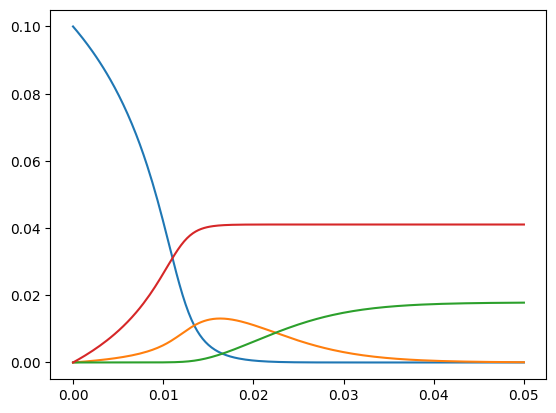

In [22]:
t=vdv_sim_result['t']
c=vdv_sim_result['y']
for i in range(4):
    plt.plot(t,c[i])